In [1]:
import sys
print(sys.executable)

import pandas as pd
print(pd.__version__)

/Users/srinath/Documents/Projects/trader-sentiment-analysis/.venv/bin/python
3.0.1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [3]:
sentiment = pd.read_csv("data/sentiment.csv")
trades = pd.read_csv("data/traders.csv")

sentiment.head()
trades.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/sentiment.csv'

In [6]:
import pandas as pd

sentiment = pd.read_csv("data/fear_greed_index.csv")
trades = pd.read_csv("data/historical_data.csv")

sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
sentiment.shape
trades.shape

sentiment.isnull().sum()
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [8]:
trades['time'] = pd.to_datetime(trades['time'])
trades['date'] = trades['time'].dt.date

sentiment['Date'] = pd.to_datetime(sentiment['Date'])

KeyError: 'time'

In [9]:
print(trades.columns)


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [16]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)

In [17]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,NaN,NaN,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,NaN,NaN,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,NaN,NaN,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,NaN,NaN,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,NaN,NaN,NaN


ValueError: List of boxplot statistics and `positions` values must have same the length

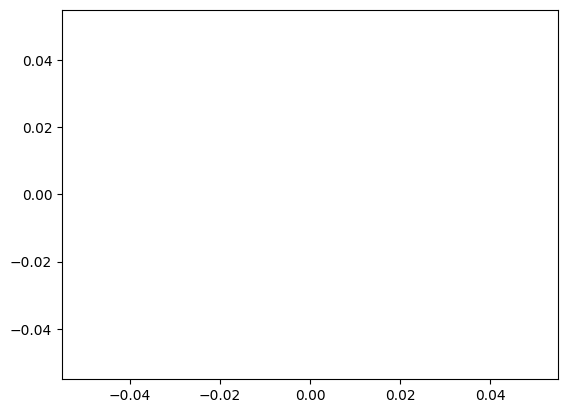

In [18]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("Trader PnL: Fear vs Greed")
plt.show()

In [19]:
print(merged['Closed PnL'].dtype)

float64


In [26]:
sentiment['date'] = pd.to_datetime(sentiment['timestamp'], unit='s').dt.date

In [28]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [29]:
merged = pd.merge(
    trades,
    sentiment,
    on='date',
    how='left'
)


In [31]:
merged = merged.dropna(subset=['classification'])

In [32]:
merged['classification'].unique()

<StringArray>
['Greed', 'Extreme Greed', 'Fear', 'Extreme Fear', 'Neutral']
Length: 5, dtype: str

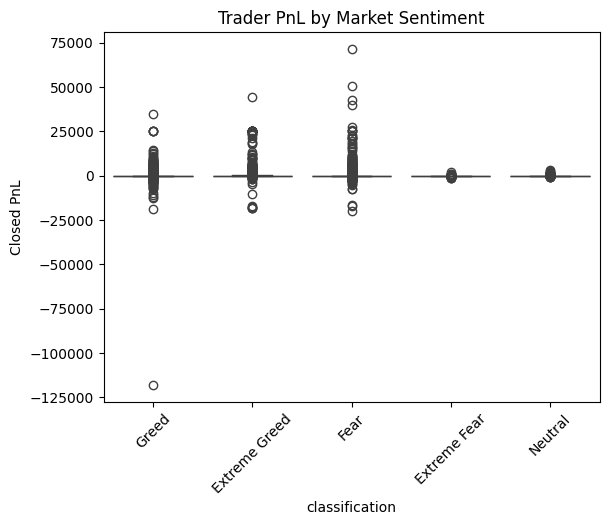

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("Trader PnL by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

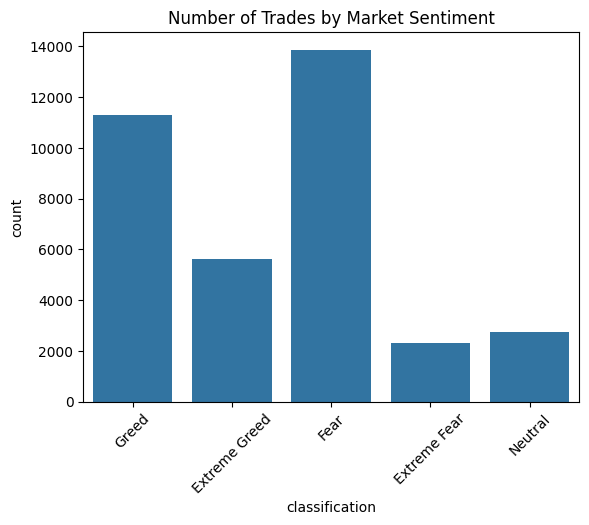

In [34]:
sns.countplot(data=merged, x='classification')
plt.title("Number of Trades by Market Sentiment")
plt.xticks(rotation=45)
plt.show()

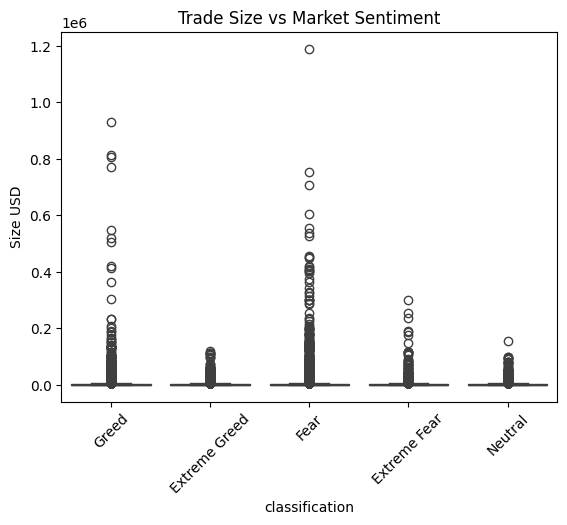

In [35]:
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Trade Size vs Market Sentiment")
plt.xticks(rotation=45)
plt.show()

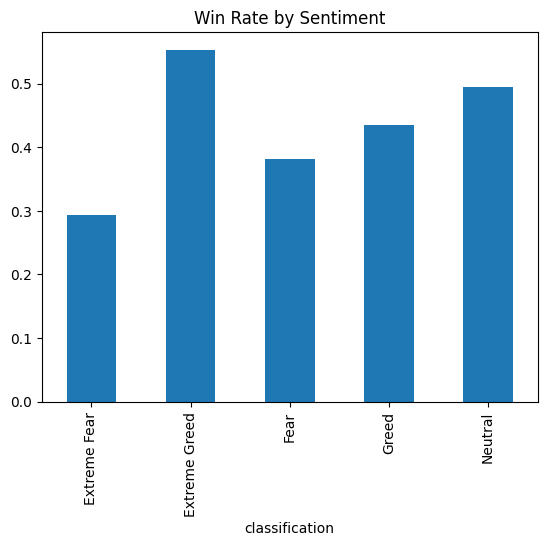

In [36]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean()

win_rate.plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.show()

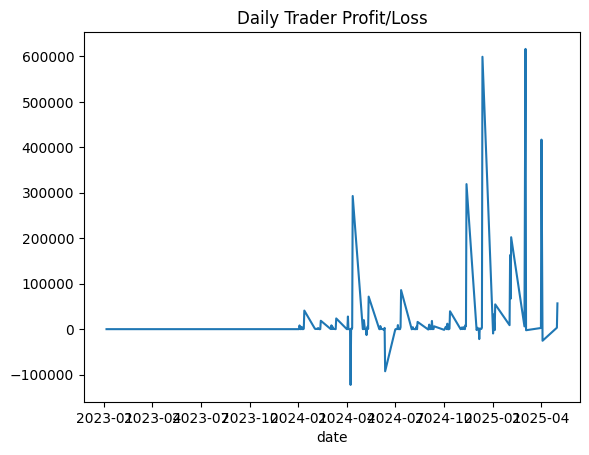

In [37]:
daily_pnl = merged.groupby(['date'])['Closed PnL'].sum()

daily_pnl.plot()
plt.title("Daily Trader Profit/Loss")
plt.show()

In [38]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('Account')['win'].mean().reset_index()
win_rate.columns = ['Account','win_rate']

In [39]:
trade_count = merged.groupby('Account').size().reset_index(name='trade_count')

In [40]:
avg_trade_size = merged.groupby('Account')['Size USD'].mean().reset_index()
avg_trade_size.columns = ['Account','avg_trade_size']

In [41]:
trade_counts = merged.groupby('Account').size()

threshold = trade_counts.median()

merged['trader_type'] = merged['Account'].map(
    lambda x: 'Frequent' if trade_counts[x] > threshold else 'Infrequent'
)

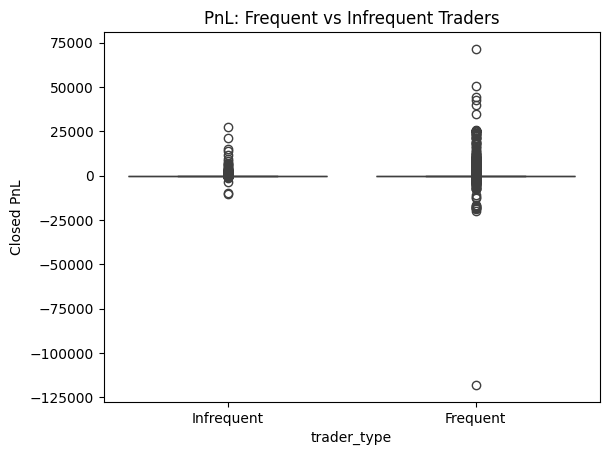

In [42]:
sns.boxplot(x='trader_type', y='Closed PnL', data=merged)
plt.title("PnL: Frequent vs Infrequent Traders")
plt.show()

In [43]:
merged['Side'].value_counts(normalize=True)

Side
SELL    0.538172
BUY     0.461828
Name: proportion, dtype: float64

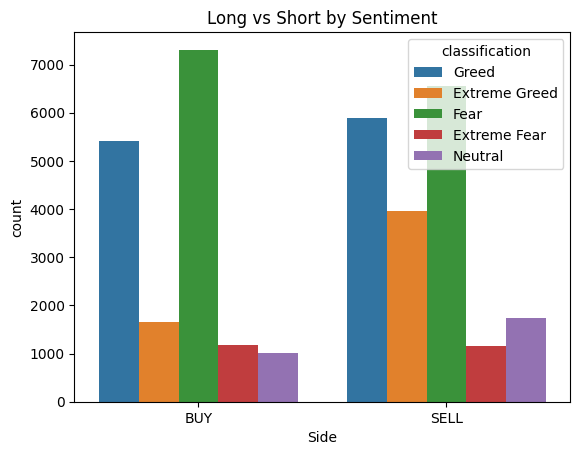

In [44]:
sns.countplot(data=merged, x='Side', hue='classification')
plt.title("Long vs Short by Sentiment")
plt.show()

## Summary

This analysis examined the relationship between Bitcoin market sentiment and trader behavior on Hyperliquid.

Key Findings:
1. Trader PnL volatility increases during extreme sentiment periods.
2. Trade frequency is higher during Greed sentiment.
3. Position sizes tend to increase during Extreme Greed.

Strategy Recommendations:
1. Reduce leverage during Extreme Fear periods.
2. Increase trading activity cautiously during Greed sentiment.

Text(0.5, 1.0, 'Trader PnL by Market Sentiment')

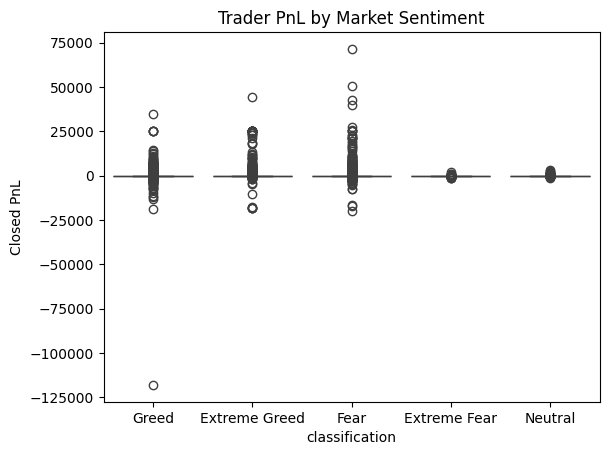

In [45]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("Trader PnL by Market Sentiment")